### Weather + Italy Energy Gap Models
Single-horizon (1-step) and Multi-horizon (1-12h) forecasting with holdout test evaluation.

In [23]:
%pip install skl2onnx onnx onnxruntime joblib openpyxl


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import glob

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import RegressorChain

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as rt

In [25]:
BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR = os.path.join(BASE_DIR, "data")
DEMAND_DIR = os.path.join(DATA_DIR, "demand")
GEN_DIR = os.path.join(DATA_DIR, "generation")
WEATHER_PATH = os.path.join(DATA_DIR, "italy_rome_2016-02-21_2026-02-21_hourly.csv")

# Holdout test window
TEST_START = pd.Timestamp("2026-02-09 00:00:00")
TEST_END   = pd.Timestamp("2026-02-16 00:00:00")

# Output directory for saved models
MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)

### Load All Demand and Generation Datasets in a Loop

In [26]:
def load_xlsx_files(directory, label=""):
    """Load all .xlsx files from a directory, concatenate, and clean metadata rows."""
    files = sorted(glob.glob(os.path.join(directory, "*.xlsx")))
    print(f"Found {len(files)} {label} files:")
    frames = []
    for f in files:
        df = pd.read_excel(f)
        # Remove metadata footer rows (e.g. 'Applied filters: ...')
        df = df[~df["Date"].astype(str).str.contains("Applied|filter", na=True)]
        df = df.dropna(subset=["Date"])
        df["Date"] = pd.to_datetime(df["Date"])
        print(f"  {os.path.basename(f)}: {df.shape}, {df['Date'].min()} -> {df['Date'].max()}")
        frames.append(df)
    combined = pd.concat(frames, ignore_index=True)
    combined = combined.drop_duplicates().sort_values("Date").reset_index(drop=True)
    print(f"  Combined {label}: {combined.shape}, {combined['Date'].min()} -> {combined['Date'].max()}")
    return combined


italy_demand_raw = load_xlsx_files(DEMAND_DIR, label="demand")
print()
italy_gen_raw = load_xlsx_files(GEN_DIR, label="generation")

Found 6 demand files:


/Users/sm_aswin21/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


  Export-DownloadCenterFile-20260221-195547.xlsx: (39168, 4), 2026-01-01 00:00:00 -> 2026-02-20 23:45:00


/Users/sm_aswin21/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


  Export-DownloadCenterFile-20260221-195700.xlsx: (280320, 4), 2025-01-01 00:00:00 -> 2025-12-31 23:45:00


...

  Export-DownloadCenterFile-20260221-195402.xlsx: (52560, 3), 2023-01-01 00:00:00 -> 2023-12-31 23:00:00


/Users/sm_aswin21/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


  Export-DownloadCenterFile-20260221-195432.xlsx: (52560, 3), 2022-01-01 00:00:00 -> 2022-12-31 23:00:00


/Users/sm_aswin21/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


  Export-DownloadCenterFile-20260221-195437.xlsx: (52560, 3), 2021-01-01 00:00:00 -> 2021-12-31 23:00:00
  Combined generation: (449952, 3), 2021-01-01 00:00:00 -> 2026-02-20 23:45:00


In [27]:
# Load weather
italy_weather = pd.read_csv(WEATHER_PATH)
print(f"Weather shape: {italy_weather.shape}")
print(f"Weather columns: {list(italy_weather.columns)}")
print(italy_weather.head(3))

Weather shape: (87696, 14)
Weather columns: ['country', 'country_code', 'location', 'time', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'wind_direction_10m', 'surface_pressure', 'cloud_cover', 'latitude_used', 'longitude_used', 'timezone']
  country country_code location                 time  temperature_2m  \
0   Italy           IT     Rome  2016-02-21 00:00:00             5.6   
1   Italy           IT     Rome  2016-02-21 01:00:00             5.3   
2   Italy           IT     Rome  2016-02-21 02:00:00             4.6   

   relative_humidity_2m  precipitation  wind_speed_10m  wind_direction_10m  \
0                  80.0            0.0             1.6               333.0   
1                  81.0            0.0             1.5                45.0   
2                  84.0            0.0             2.3                72.0   

   surface_pressure  cloud_cover  latitude_used  longitude_used     timezone  
0            1020.3          0.0           42.

In [28]:
print("Demand columns:", list(italy_demand_raw.columns))
print("Demand zones:", sorted(italy_demand_raw["Bidding Zone"].unique()))
print()
print("Generation columns:", list(italy_gen_raw.columns))
print("Generation sources:", sorted(italy_gen_raw["Primary Source"].unique()))
print()
print(f"Demand time range: {italy_demand_raw['Date'].min()} -> {italy_demand_raw['Date'].max()}")
print(f"Generation time range: {italy_gen_raw['Date'].min()} -> {italy_gen_raw['Date'].max()}")

Demand columns: ['Date', 'Total Load [MW]', 'Forecast Total Load [MW]', 'Bidding Zone']
Demand zones: ['Calabria', 'Centre-North', 'Centre-South', 'Italy', 'North', 'Sardinia', 'Sicily', 'South']

Generation columns: ['Date', 'Actual Generation', 'Primary Source']
Generation sources: ['Geothermal', 'Hydro', 'Photovoltaic', 'Self-consumption', 'Thermal', 'Wind']

Demand time range: 2021-02-01 00:00:00 -> 2026-02-20 23:45:00
Generation time range: 2021-01-01 00:00:00 -> 2026-02-20 23:45:00


### Data Merging and Preprocessing

In [29]:
# --- Demand: filter to national 'Italy' aggregate, rename ---
italy_demand = (
    italy_demand_raw[italy_demand_raw["Bidding Zone"] == "Italy"]
    .rename(columns={"Date": "StartTime", "Total Load [MW]": "Demand"})
    [["StartTime", "Demand"]]
    .sort_values("StartTime")
    .reset_index(drop=True)
)

# --- Generation: sum all sources per timestamp, convert GW -> MW ---
italy_gen = (
    italy_gen_raw
    .groupby("Date")["Actual Generation"]
    .sum()
    .reset_index()
    .rename(columns={"Date": "StartTime", "Actual Generation": "Total_Generation"})
)
# Generation is in GW, demand is in MW -- convert to MW
italy_gen["Total_Generation"] = italy_gen["Total_Generation"] * 1000.0

# --- Merge demand + generation ---
df = italy_demand.merge(italy_gen, on="StartTime", how="inner")
df["Gap"] = df["Total_Generation"] - df["Demand"]
df = df.sort_values("StartTime").reset_index(drop=True)

print(f"Merged demand+generation shape: {df.shape}")
print(f"Date range: {df['StartTime'].min()} -> {df['StartTime'].max()}")
print(df.head())

Merged demand+generation shape: (50730, 4)
Date range: 2021-02-01 00:00:00 -> 2026-02-20 23:45:00
            StartTime     Demand  Total_Generation       Gap
0 2021-02-01 00:00:00  25969.000           20788.0 -5181.000
1 2021-02-01 01:00:00  24155.001           20370.0 -3785.001
2 2021-02-01 02:00:00  23328.000           20623.0 -2705.000
3 2021-02-01 03:00:00  23382.001           20222.0 -3160.001
4 2021-02-01 04:00:00  23402.001           19830.0 -3572.001


In [30]:
# Prepare weather + align datetime
italy_weather = italy_weather.rename(columns={"time": "StartTime"})
italy_weather["StartTime"] = pd.to_datetime(italy_weather["StartTime"])

# Resample demand/gen/gap to hourly (mean) to match weather granularity
cols = ["Demand", "Total_Generation", "Gap"]
df_hourly = (
    df.set_index("StartTime")[cols]
      .resample("H")
      .mean()
      .reset_index()
)

# Normalize timezone handling
df_hourly["StartTime"] = pd.to_datetime(df_hourly["StartTime"], utc=True).dt.tz_convert(None)
italy_weather["StartTime"] = pd.to_datetime(italy_weather["StartTime"], utc=True).dt.tz_convert(None)

# Merge hourly df with weather
df_final = df_hourly.merge(italy_weather, on="StartTime", how="left")
df_final = df_final.dropna().reset_index(drop=True)
print(f"Final merged shape: {df_final.shape}")

Final merged shape: (20663, 17)


### Feature Engineering

In [31]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["hour"] = df["StartTime"].dt.hour
    df["day_of_week"] = df["StartTime"].dt.dayofweek
    df["month"] = df["StartTime"].dt.month
    df["day_of_year"] = df["StartTime"].dt.dayofyear
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    return df


def add_lag_rolling_features(
    df: pd.DataFrame,
    target_col: str = "Gap",
    extra_series_cols=("Demand", "Total_Generation"),
    lags=(1, 2, 3, 6, 12, 24, 48, 168),
    rolls=(3, 6, 24, 168)
) -> pd.DataFrame:
    df = df.copy()

    for L in lags:
        df[f"{target_col}_lag_{L}"] = df[target_col].shift(L)

    shifted = df[target_col].shift(1)
    for W in rolls:
        df[f"{target_col}_roll_mean_{W}"] = shifted.rolling(W).mean()
        df[f"{target_col}_roll_std_{W}"] = shifted.rolling(W).std()
        df[f"{target_col}_roll_min_{W}"] = shifted.rolling(W).min()
        df[f"{target_col}_roll_max_{W}"] = shifted.rolling(W).max()

    for col in extra_series_cols:
        for L in lags:
            df[f"{col}_lag_{L}"] = df[col].shift(L)
        shifted_col = df[col].shift(1)
        for W in rolls:
            df[f"{col}_roll_mean_{W}"] = shifted_col.rolling(W).mean()
            df[f"{col}_roll_std_{W}"] = shifted_col.rolling(W).std()

    df[f"{target_col}_diff_1"] = df[target_col].diff(1)
    df[f"{target_col}_diff_24"] = df[target_col].diff(24)

    if "temperature_2m" in df.columns:
        df["temp_diff_1"] = df["temperature_2m"].diff(1)
        df["temp_diff_24"] = df["temperature_2m"].diff(24)

    return df


def make_supervised(df: pd.DataFrame, horizon: int = 1, target_col: str = "Gap") -> pd.DataFrame:
    df = df.copy()
    df["y"] = df[target_col].shift(-horizon)
    df = df.dropna(subset=["y"])
    return df


def rmse(y_true, y_pred) -> float:
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mape(y_true, y_pred, eps: float = 1e-6) -> float:
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100


WEATHER_COLS = [
    "temperature_2m", "relative_humidity_2m", "precipitation",
    "wind_speed_10m", "wind_direction_10m", "surface_pressure", "cloud_cover",
    "latitude_used", "longitude_used"
]

TIME_COLS_CYCLIC = [
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "month_sin", "month_cos", "day_of_year", "is_weekend"
]

---
## PART 1 -- Single-Horizon Model (1-step ahead)

In [32]:
HORIZON = 1

df_feat = add_time_features(df_final)
df_feat = add_lag_rolling_features(df_feat)
df_feat = make_supervised(df_feat, horizon=HORIZON, target_col="Gap")
df_feat = df_feat.dropna().reset_index(drop=True)

lag_roll_cols_single = [
    c for c in df_feat.columns
    if ("_lag_" in c) or ("_roll_" in c) or ("_diff_" in c)
]

feature_cols_single = WEATHER_COLS + TIME_COLS_CYCLIC + lag_roll_cols_single
feature_cols_single = [c for c in feature_cols_single if c in df_feat.columns]

X_single = df_feat[feature_cols_single].reset_index(drop=True)
y_single = df_feat["y"].reset_index(drop=True)
times_single = df_feat["StartTime"].reset_index(drop=True)

print(f"[Single-Horizon] X: {X_single.shape}, y: {y_single.shape}")

[Single-Horizon] X: (20494, 77), y: (20494,)


#### Single-Horizon: Holdout Test (Feb 9 -- Feb 16)

In [33]:
# Split using TEST_START / TEST_END
test_end_for_X = TEST_END - pd.Timedelta(hours=HORIZON)

train_mask_s = times_single < TEST_START
test_mask_s  = (times_single >= TEST_START) & (times_single < test_end_for_X)

X_train_s, X_test_s = X_single.loc[train_mask_s], X_single.loc[test_mask_s]
y_train_s, y_test_s = y_single.loc[train_mask_s], y_single.loc[test_mask_s]

print("Single-horizon holdout split:")
print(f"  TEST_START: {TEST_START}")
print(f"  TEST_END:   {TEST_END}")
print(f"  Train: {times_single.loc[train_mask_s].min()} -> {times_single.loc[train_mask_s].max()} | n={int(train_mask_s.sum())}")
print(f"  Test:  {times_single.loc[test_mask_s].min()} -> {times_single.loc[test_mask_s].max()} | n={int(test_mask_s.sum())}")

model_single = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("reg", HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=8,
        max_iter=500,
        random_state=42
    ))
])

model_single.fit(X_train_s, y_train_s)
preds_s = model_single.predict(X_test_s)

print(f"\n[Single-Horizon] Holdout Test Results ({TEST_START.date()} to {TEST_END.date()}):")
print(f"  MAE:    {mean_absolute_error(y_test_s, preds_s):.2f}")
print(f"  RMSE:   {rmse(y_test_s, preds_s):.2f}")
print(f"  R2:     {r2_score(y_test_s, preds_s):.4f}")
print(f"  MAPE %: {mape(y_test_s.values, preds_s):.2f}")

Single-horizon holdout split:
  TEST_START: 2026-02-09 00:00:00
  TEST_END:   2026-02-16 00:00:00
  Train: 2021-02-08 00:00:00 -> 2026-02-08 23:00:00 | n=20326
  Test:  2026-02-09 00:00:00 -> 2026-02-15 22:00:00 | n=167

[Single-Horizon] Holdout Test Results (2026-02-09 to 2026-02-16):
  MAE:    555.64
  RMSE:   698.32
  R2:     0.8451
  MAPE %: 18.39


#### Single-Horizon: TimeSeries Cross-Validation

In [ ]:
TEST_SIZE = 30 * 24
tscv = TimeSeriesSplit(n_splits=5, test_size=TEST_SIZE)

fold_results_s = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_single), start=1):
    Xtr, Xte = X_single.iloc[train_idx], X_single.iloc[test_idx]
    ytr, yte = y_single.iloc[train_idx], y_single.iloc[test_idx]

    model_single.fit(Xtr, ytr)
    p = model_single.predict(Xte)

    fold_results_s.append({
        "fold":   fold,
        "MAE":    mean_absolute_error(yte, p),
        "RMSE":   rmse(yte, p),
        "R2":     r2_score(yte, p),
        "MAPE_%": mape(yte.values, p)
    })

results_single_cv = pd.DataFrame(fold_results_s)
print("[Single-Horizon] CV Results:")
print(results_single_cv)
print(f"\nMean:\n{results_single_cv[['MAE', 'RMSE', 'R2', 'MAPE_%']].mean()}")
print(f"\nStd:\n{results_single_cv[['MAE', 'RMSE', 'R2', 'MAPE_%']].std()}")

#### Single-Horizon: Refit on train (up to TEST_START), save ONNX + weights

In [ ]:
# Refit on training data (everything before TEST_START) for the final saved model
print("Refitting single-horizon model on train data (up to TEST_START)...")
model_single.fit(X_train_s, y_train_s)

# Save sklearn weights (joblib)
joblib_path_single = os.path.join(MODEL_DIR, "gap_single_horizon.joblib")
joblib.dump(model_single, joblib_path_single)
print(f"Saved sklearn weights: {joblib_path_single}")

# Save ONNX
initial_type_single = [("float_input", FloatTensorType([None, X_single.shape[1]]))]
onnx_single = convert_sklearn(model_single, initial_types=initial_type_single, target_opset=17)

onnx_path_single = os.path.join(MODEL_DIR, "gap_single_horizon.onnx")
with open(onnx_path_single, "wb") as f:
    f.write(onnx_single.SerializeToString())
print(f"Saved ONNX model: {onnx_path_single}")

# Save feature columns list for inference
joblib.dump(feature_cols_single, os.path.join(MODEL_DIR, "feature_cols_single.joblib"))

# Sanity check ONNX
sess_single = rt.InferenceSession(onnx_path_single)
sample = X_test_s.iloc[:3].values.astype(np.float32)
preds_onnx = sess_single.run(None, {sess_single.get_inputs()[0].name: sample})
print(f"ONNX sanity check output shape: {np.array(preds_onnx[0]).shape}")

# Verify ONNX matches sklearn
preds_sk = model_single.predict(X_test_s.iloc[:3])
print(f"Max difference sklearn vs ONNX: {np.max(np.abs(preds_sk - preds_onnx[0].flatten())):.6f}")

Refitting single-horizon model on train data (up to TEST_START)...


Saved sklearn weights: saved_models/gap_single_horizon.joblib
Saved ONNX model: saved_models/gap_single_horizon.onnx
ONNX sanity check output shape: (3, 1)
Max difference sklearn vs ONNX: 0.000450


In [ ]:
# Save single-horizon test set as parquet and npy
test_df_single = X_test_s.copy()
test_df_single["StartTime"] = times_single.loc[test_mask_s].values
test_df_single["y_true"] = y_test_s.values
test_df_single["y_pred"] = preds_s
test_df_single.to_parquet(os.path.join(MODEL_DIR, "test_single_horizon.parquet"), index=False)
np.save(os.path.join(MODEL_DIR, "test_single_horizon_X.npy"), X_test_s.values)
np.save(os.path.join(MODEL_DIR, "test_single_horizon_y.npy"), y_test_s.values)
print(f"Saved test_single_horizon.parquet  shape: {test_df_single.shape}")
print(f"Saved test_single_horizon_X.npy    shape: {X_test_s.values.shape}")
print(f"Saved test_single_horizon_y.npy    shape: {y_test_s.values.shape}")

Saved test_single_horizon.parquet  shape: (167, 80)
Saved test_single_horizon_X.npy    shape: (167, 77)
Saved test_single_horizon_y.npy    shape: (167,)


---
## PART 2 -- Multi-Horizon Model 

In [ ]:
HORIZONS = range(1, 13)

df_model = df_final.sort_values("StartTime").reset_index(drop=True).copy()
df_model = add_time_features(df_model)
independent_cols = df_model.columns.tolist()

# Create future targets
for h in HORIZONS:
    df_model[f"Gap_t_plus_{h}h"] = df_model["Gap"].shift(-h)

dependent_cols = [c for c in df_model.columns if c not in independent_cols]
print(f"[Multi-Horizon] Target columns ({len(dependent_cols)}): {dependent_cols}")


def add_lags(df: pd.DataFrame, col: str, lags=(1, 2, 3, 6, 12, 24, 48, 168)) -> pd.DataFrame:
    df = df.copy()
    for L in lags:
        df[f"{col}_lag_{L}"] = df[col].shift(L)
    return df


def add_rolls(df: pd.DataFrame, col: str, windows=(3, 6, 24, 168)) -> pd.DataFrame:
    df = df.copy()
    s = df[col].shift(1)
    for W in windows:
        df[f"{col}_roll_mean_{W}"] = s.rolling(W).mean()
        df[f"{col}_roll_std_{W}"]  = s.rolling(W).std()
    return df


df_model = add_lags(df_model, "Gap")
df_model = add_rolls(df_model, "Gap")
df_model = add_lags(df_model, "Demand")
df_model = add_lags(df_model, "Total_Generation")

df_model["Gap_diff_1"]  = df_model["Gap"].diff(1)
df_model["Gap_diff_24"] = df_model["Gap"].diff(24)
if "temperature_2m" in df_model.columns:
    df_model["temp_diff_1"]  = df_model["temperature_2m"].diff(1)
    df_model["temp_diff_24"] = df_model["temperature_2m"].diff(24)

lag_roll_cols_multi = [
    c for c in df_model.columns
    if ("_lag_" in c) or ("_roll_" in c) or ("_diff_" in c)
]

feature_cols_multi = WEATHER_COLS + TIME_COLS_CYCLIC + lag_roll_cols_multi
feature_cols_multi = [c for c in feature_cols_multi if c in df_model.columns]

# Drop NaNs
data = pd.concat([df_model[feature_cols_multi], df_model[dependent_cols], df_model[["StartTime"]]], axis=1)
data = data.dropna().reset_index(drop=True)

X_multi = data[feature_cols_multi]
Y_multi = data[dependent_cols]
times_multi = data["StartTime"]

print(f"[Multi-Horizon] X: {X_multi.shape}, Y: {Y_multi.shape}")

[Multi-Horizon] Target columns (12): ['Gap_t_plus_1h', 'Gap_t_plus_2h', 'Gap_t_plus_3h', 'Gap_t_plus_4h', 'Gap_t_plus_5h', 'Gap_t_plus_6h', 'Gap_t_plus_7h', 'Gap_t_plus_8h', 'Gap_t_plus_9h', 'Gap_t_plus_10h', 'Gap_t_plus_11h', 'Gap_t_plus_12h']
[Multi-Horizon] X: (20483, 53), Y: (20483, 12)


#### Multi-Horizon: Holdout Test (Feb 9 -- Feb 16)

In [ ]:
# For multi-horizon, the latest target is Gap(t+12), so exclude feature rows
# where t+12 >= TEST_END
max_horizon = max(HORIZONS)
test_end_for_X_multi = TEST_END - pd.Timedelta(hours=max_horizon)

train_mask_m = times_multi < TEST_START
test_mask_m  = (times_multi >= TEST_START) & (times_multi < test_end_for_X_multi)

X_train_m, X_test_m = X_multi.loc[train_mask_m], X_multi.loc[test_mask_m]
Y_train_m, Y_test_m = Y_multi.loc[train_mask_m], Y_multi.loc[test_mask_m]

print("Multi-horizon holdout split:")
print(f"  TEST_START: {TEST_START}")
print(f"  TEST_END:   {TEST_END}")
print(f"  Train: {times_multi.loc[train_mask_m].min()} -> {times_multi.loc[train_mask_m].max()} | n={int(train_mask_m.sum())}")
print(f"  Test:  {times_multi.loc[test_mask_m].min()} -> {times_multi.loc[test_mask_m].max()} | n={int(test_mask_m.sum())}")

base_estimator = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=8,
    max_iter=500,
    random_state=42
)
model_multi = RegressorChain(base_estimator, order=list(range(12)))

model_multi.fit(X_train_m, Y_train_m)
Y_pred_m = model_multi.predict(X_test_m)

print(f"\n[Multi-Horizon] Holdout Test Results ({TEST_START.date()} to {TEST_END.date()}):")
holdout_rows = []
for j, h in enumerate(HORIZONS):
    y_true_h = Y_test_m.iloc[:, j].values
    y_pred_h = Y_pred_m[:, j]
    holdout_rows.append({
        "horizon_h": h,
        "MAE":  mean_absolute_error(y_true_h, y_pred_h),
        "RMSE": rmse(y_true_h, y_pred_h),
        "R2":   r2_score(y_true_h, y_pred_h),
    })

holdout_multi = pd.DataFrame(holdout_rows).set_index("horizon_h")
print(holdout_multi)
print(f"\nOverall mean:\n{holdout_multi.mean()}")

Multi-horizon holdout split:
  TEST_START: 2026-02-09 00:00:00
  TEST_END:   2026-02-16 00:00:00
  Train: 2021-02-08 00:00:00 -> 2026-02-08 23:00:00 | n=20326
  Test:  2026-02-09 00:00:00 -> 2026-02-15 11:00:00 | n=156



[Multi-Horizon] Holdout Test Results (2026-02-09 to 2026-02-16):
                   MAE         RMSE        R2
horizon_h                                    
1           557.071302   709.939352  0.774934
2           816.561350  1079.340583  0.543929
3          1002.752423  1337.739493  0.371334
4          1122.274702  1499.268838  0.250979
5          1228.577653  1626.816703  0.124652
6          1291.142090  1711.230743  0.029628
7          1349.167627  1792.086831 -0.053427
8          1397.816967  1829.667084 -0.079581
9          1429.512330  1840.646729 -0.061357
10         1384.479519  1830.878919 -0.033628
11         1318.017690  1798.557587  0.011441
12         1246.436573  1750.856587  0.065433

Overall mean:
MAE     1178.650852
RMSE    1567.252454
R2         0.162028
dtype: float64


#### Multi-Horizon: TimeSeries Cross-Validation

In [ ]:
TEST_SIZE = 30 * 24
tscv = TimeSeriesSplit(n_splits=5, test_size=TEST_SIZE)

cv_rows_m = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_multi), start=1):
    Xtr, Xte = X_multi.iloc[train_idx], X_multi.iloc[test_idx]
    Ytr, Yte = Y_multi.iloc[train_idx], Y_multi.iloc[test_idx]

    model_multi.fit(Xtr, Ytr)
    Yp = model_multi.predict(Xte)

    for j, h in enumerate(HORIZONS):
        y_true_h = Yte.iloc[:, j].values
        y_pred_h = Yp[:, j]
        cv_rows_m.append({
            "fold":      fold,
            "horizon_h": h,
            "MAE":       mean_absolute_error(y_true_h, y_pred_h),
            "RMSE":      rmse(y_true_h, y_pred_h),
            "R2":        r2_score(y_true_h, y_pred_h),
        })

results_multi_cv = pd.DataFrame(cv_rows_m)

print("[Multi-Horizon] Per-horizon mean across folds:")
summary = results_multi_cv.groupby("horizon_h")[["MAE", "RMSE", "R2"]].mean()
print(summary)
print(f"\nOverall mean:\n{results_multi_cv[['MAE', 'RMSE', 'R2']].mean()}")

try:
    display(
        summary.style
        .background_gradient(subset=["MAE", "RMSE"], cmap="Reds_r", axis=0)
        .background_gradient(subset=["R2"],           cmap="Greens",  axis=0)
        .format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "R2": "{:.3f}"})
    )
except NameError:
    pass

[Multi-Horizon] Per-horizon mean across folds:
                   MAE         RMSE        R2
horizon_h                                    
1           532.088322   723.408604  0.825542
2           849.128720  1105.894473  0.607551
3          1047.569853  1353.487600  0.423518
4          1154.281334  1489.998546  0.309355
5          1208.494478  1558.079653  0.245249
6          1227.728647  1577.889021  0.226616
7          1222.633903  1582.982667  0.223809
8          1216.034549  1582.321556  0.225267
9          1216.428487  1586.906240  0.221166
10         1202.944190  1570.299069  0.239109
11         1166.070902  1533.557710  0.275781
12         1153.835918  1526.701744  0.282540

Overall mean:
MAE     1099.769942
RMSE    1432.627240
R2         0.342125
dtype: float64


,MAE,RMSE,R2
horizon_h,,,
1,532.09,723.41,0.826
2,849.13,1105.89,0.608
3,1047.57,1353.49,0.424
4,1154.28,1490.00,0.309
5,1208.49,1558.08,0.245
6,1227.73,1577.89,0.227
7,1222.63,1582.98,0.224
8,1216.03,1582.32,0.225
9,1216.43,1586.91,0.221


#### Multi-Horizon: Refit on train (up to TEST_START), save ONNX + weights

In [ ]:
# Refit on training data (everything before TEST_START) for the final saved model
print("Refitting multi-horizon model on train data (up to TEST_START)...")
model_multi.fit(X_train_m, Y_train_m)

# Save sklearn weights (joblib)
joblib_path_multi = os.path.join(MODEL_DIR, "gap_multi_horizon.joblib")
joblib.dump(model_multi, joblib_path_multi)
print(f"Saved sklearn weights: {joblib_path_multi}")

# Save feature columns list for inference
joblib.dump(feature_cols_multi, os.path.join(MODEL_DIR, "feature_cols_multi.joblib"))

# Save ONNX (RegressorChain may not be fully supported by skl2onnx)
try:
    initial_type_multi = [("float_input", FloatTensorType([None, X_multi.shape[1]]))]
    onnx_multi = convert_sklearn(model_multi, initial_types=initial_type_multi, target_opset=17)

    onnx_path_multi = os.path.join(MODEL_DIR, "gap_multi_horizon.onnx")
    with open(onnx_path_multi, "wb") as f:
        f.write(onnx_multi.SerializeToString())
    print(f"Saved ONNX model: {onnx_path_multi}")

    # Sanity check ONNX
    sess_multi = rt.InferenceSession(onnx_path_multi)
    sample_m = X_test_m.iloc[:3].values.astype(np.float32)
    preds_onnx_m = sess_multi.run(None, {sess_multi.get_inputs()[0].name: sample_m})
    print(f"ONNX sanity check output shape: {np.array(preds_onnx_m[0]).shape}")

    # Verify ONNX matches sklearn
    preds_sk_m = model_multi.predict(X_test_m.iloc[:3])
    print(f"Max difference sklearn vs ONNX: {np.max(np.abs(preds_sk_m - preds_onnx_m[0])):.6f}")
except Exception as e:
    print(f"ONNX export failed for RegressorChain (expected): {e}")
    print("The joblib model is still saved and fully functional for inference.")

Refitting multi-horizon model on train data (up to TEST_START)...


Saved sklearn weights: saved_models/gap_multi_horizon.joblib
ONNX export failed for RegressorChain (expected): Unable to find a shape calculator for type '<class 'sklearn.multioutput.RegressorChain'>'.
It usually means the pipeline being converted contains a
transformer or a predictor with no corresponding converter
implemented in sklearn-onnx. If the converted is implemented
in another library, you need to register
the converted so that it can be used by sklearn-onnx (function
update_registered_converter). If the model is not yet covered
by sklearn-onnx, you may raise an issue to
https://github.com/onnx/sklearn-onnx/issues
to get the converter implemented or even contribute to the
project. If the model is a custom model, a new converter must
be implemented. Examples can be found in the gallery.

The joblib model is still saved and fully functional for inference.


In [ ]:
# Save multi-horizon test set as parquet and npy
test_df_multi = X_test_m.copy()
test_df_multi["StartTime"] = times_multi.loc[test_mask_m].values
for j, h in enumerate(HORIZONS):
    test_df_multi[f"y_true_{h}h"] = Y_test_m.iloc[:, j].values
    test_df_multi[f"y_pred_{h}h"] = Y_pred_m[:, j]
test_df_multi.to_parquet(os.path.join(MODEL_DIR, "test_multi_horizon.parquet"), index=False)
np.save(os.path.join(MODEL_DIR, "test_multi_horizon_X.npy"), X_test_m.values)
np.save(os.path.join(MODEL_DIR, "test_multi_horizon_Y.npy"), Y_test_m.values)
print(f"Saved test_multi_horizon.parquet  shape: {test_df_multi.shape}")
print(f"Saved test_multi_horizon_X.npy    shape: {X_test_m.values.shape}")
print(f"Saved test_multi_horizon_Y.npy    shape: {Y_test_m.values.shape}")

Saved test_multi_horizon.parquet  shape: (156, 78)
Saved test_multi_horizon_X.npy    shape: (156, 53)
Saved test_multi_horizon_Y.npy    shape: (156, 12)


---
### Summary of saved artifacts

| Model | ONNX | Weights (joblib) | Feature list |
|-------|------|------------------|--------------|
| Single-horizon (1h) | `saved_models/gap_single_horizon.onnx` | `saved_models/gap_single_horizon.joblib` | `saved_models/feature_cols_single.joblib` |
| Multi-horizon (1-12h) | `saved_models/gap_multi_horizon.onnx` | `saved_models/gap_multi_horizon.joblib` | `saved_models/feature_cols_multi.joblib` |

---
## Exploratory Data Analysis (EDA)

In [42]:
# -- Plot style setup --
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
})
eda = df_final.copy()
eda["hour"] = eda["StartTime"].dt.hour
eda["month"] = eda["StartTime"].dt.month
eda["year"] = eda["StartTime"].dt.year
eda["dayofweek"] = eda["StartTime"].dt.dayofweek
eda["day_name"] = eda["StartTime"].dt.day_name()
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
eda["month_name"] = eda["month"].map(month_names)
print(f"EDA dataframe: {eda.shape}")

EDA dataframe: (20663, 23)


### 1. Energy Time Series Overview

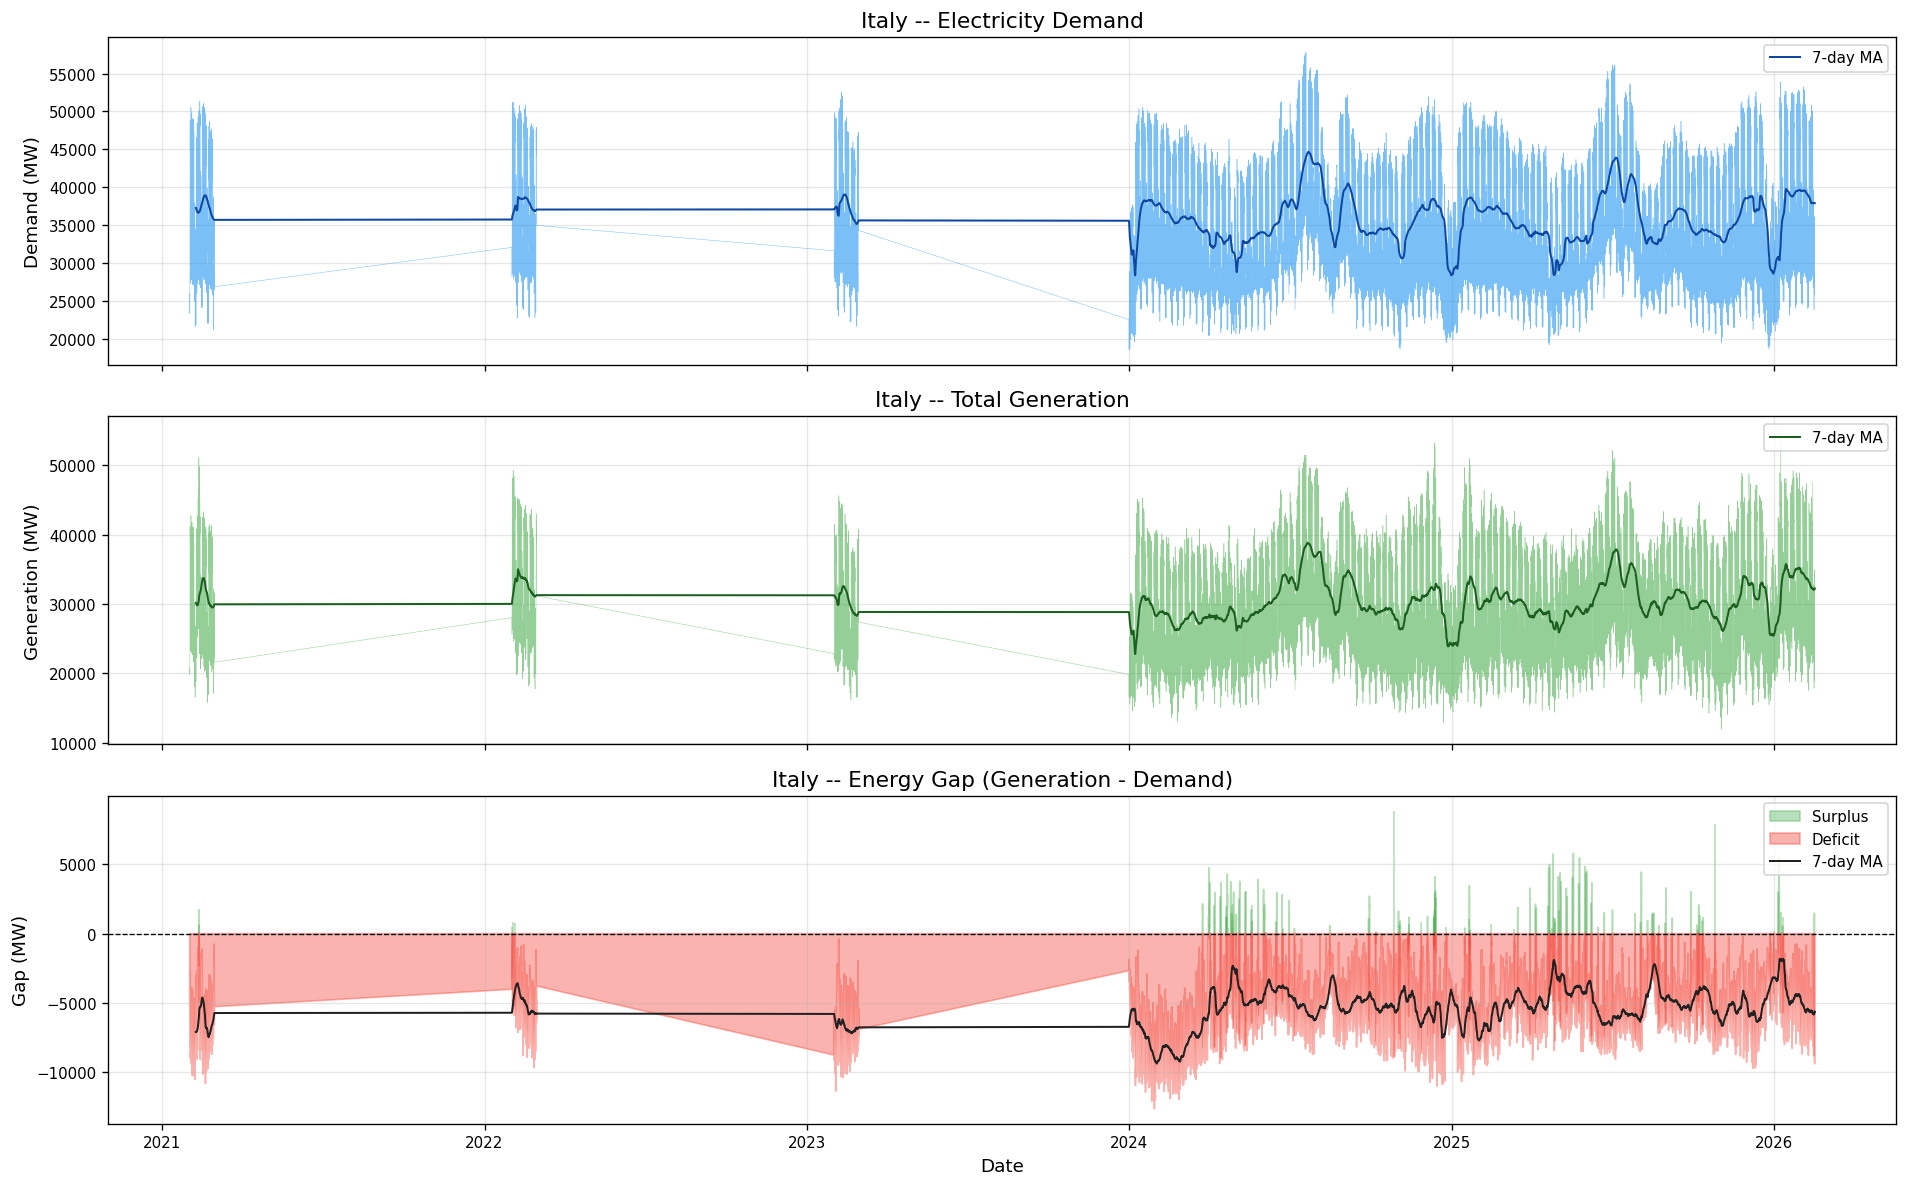

In [43]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Demand
axes[0].plot(eda["StartTime"], eda["Demand"], linewidth=0.3, color="#2196F3", alpha=0.6)
axes[0].plot(eda["StartTime"], eda["Demand"].rolling(24*7).mean(), linewidth=1.2, color="#0D47A1", label="7-day MA")
axes[0].set_ylabel("Demand (MW)")
axes[0].set_title("Italy -- Electricity Demand")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

# Generation
axes[1].plot(eda["StartTime"], eda["Total_Generation"], linewidth=0.3, color="#4CAF50", alpha=0.6)
axes[1].plot(eda["StartTime"], eda["Total_Generation"].rolling(24*7).mean(), linewidth=1.2, color="#1B5E20", label="7-day MA")
axes[1].set_ylabel("Generation (MW)")
axes[1].set_title("Italy -- Total Generation")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

# Gap
axes[2].fill_between(eda["StartTime"], eda["Gap"], 0,
                     where=eda["Gap"] >= 0, color="#4CAF50", alpha=0.4, label="Surplus")
axes[2].fill_between(eda["StartTime"], eda["Gap"], 0,
                     where=eda["Gap"] < 0, color="#F44336", alpha=0.4, label="Deficit")
axes[2].plot(eda["StartTime"], eda["Gap"].rolling(24*7).mean(), linewidth=1.2, color="#212121", label="7-day MA")
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_ylabel("Gap (MW)")
axes[2].set_xlabel("Date")
axes[2].set_title("Italy -- Energy Gap (Generation - Demand)")
axes[2].legend(loc="upper right")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2. Energy Distributions

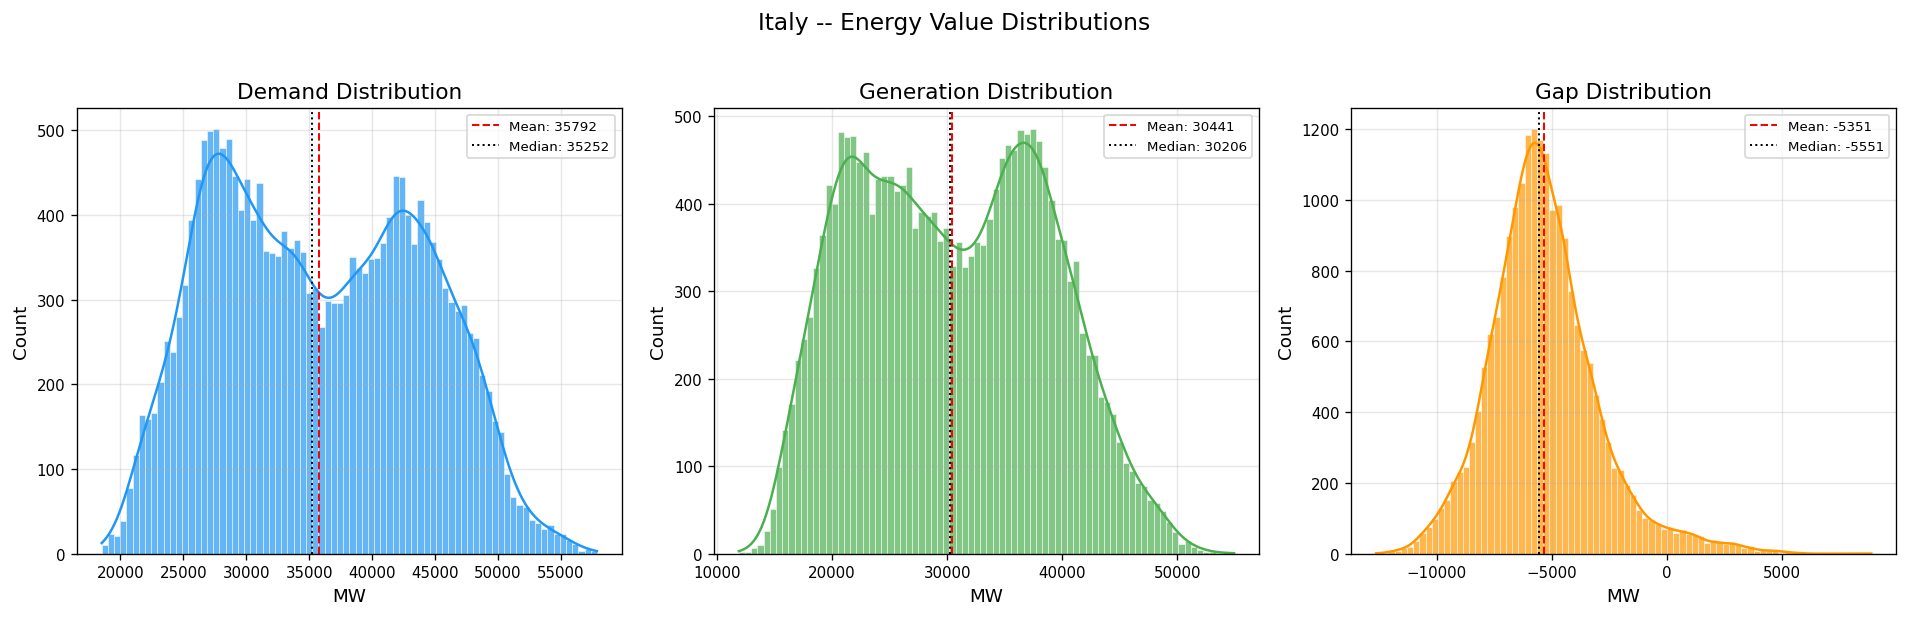

        Demand  Total_Generation      Gap
count  20663.0           20663.0  20663.0
mean   35791.5           30441.0  -5350.6
std     8226.5            8277.8   2351.9
min    18513.0           11918.0 -12635.0
25%    28657.6           23294.5  -6820.1
50%    35252.3           30206.0  -5551.0
75%    42650.6           37145.5  -4152.0
max    57862.0           54915.0   8868.0


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color, title in zip(
    axes,
    ["Demand", "Total_Generation", "Gap"],
    ["#2196F3", "#4CAF50", "#FF9800"],
    ["Demand Distribution", "Generation Distribution", "Gap Distribution"]
):
    sns.histplot(eda[col], bins=80, kde=True, ax=ax, color=color, alpha=0.7, edgecolor="white", linewidth=0.3)
    ax.axvline(eda[col].mean(), color="red", linestyle="--", linewidth=1.2, label=f"Mean: {eda[col].mean():.0f}")
    ax.axvline(eda[col].median(), color="black", linestyle=":", linewidth=1.2, label=f"Median: {eda[col].median():.0f}")
    ax.set_title(title)
    ax.set_xlabel("MW")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Italy -- Energy Value Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print summary statistics
print(eda[["Demand", "Total_Generation", "Gap"]].describe().round(1))

### 3. Gap Analysis -- Diurnal and Seasonal Patterns

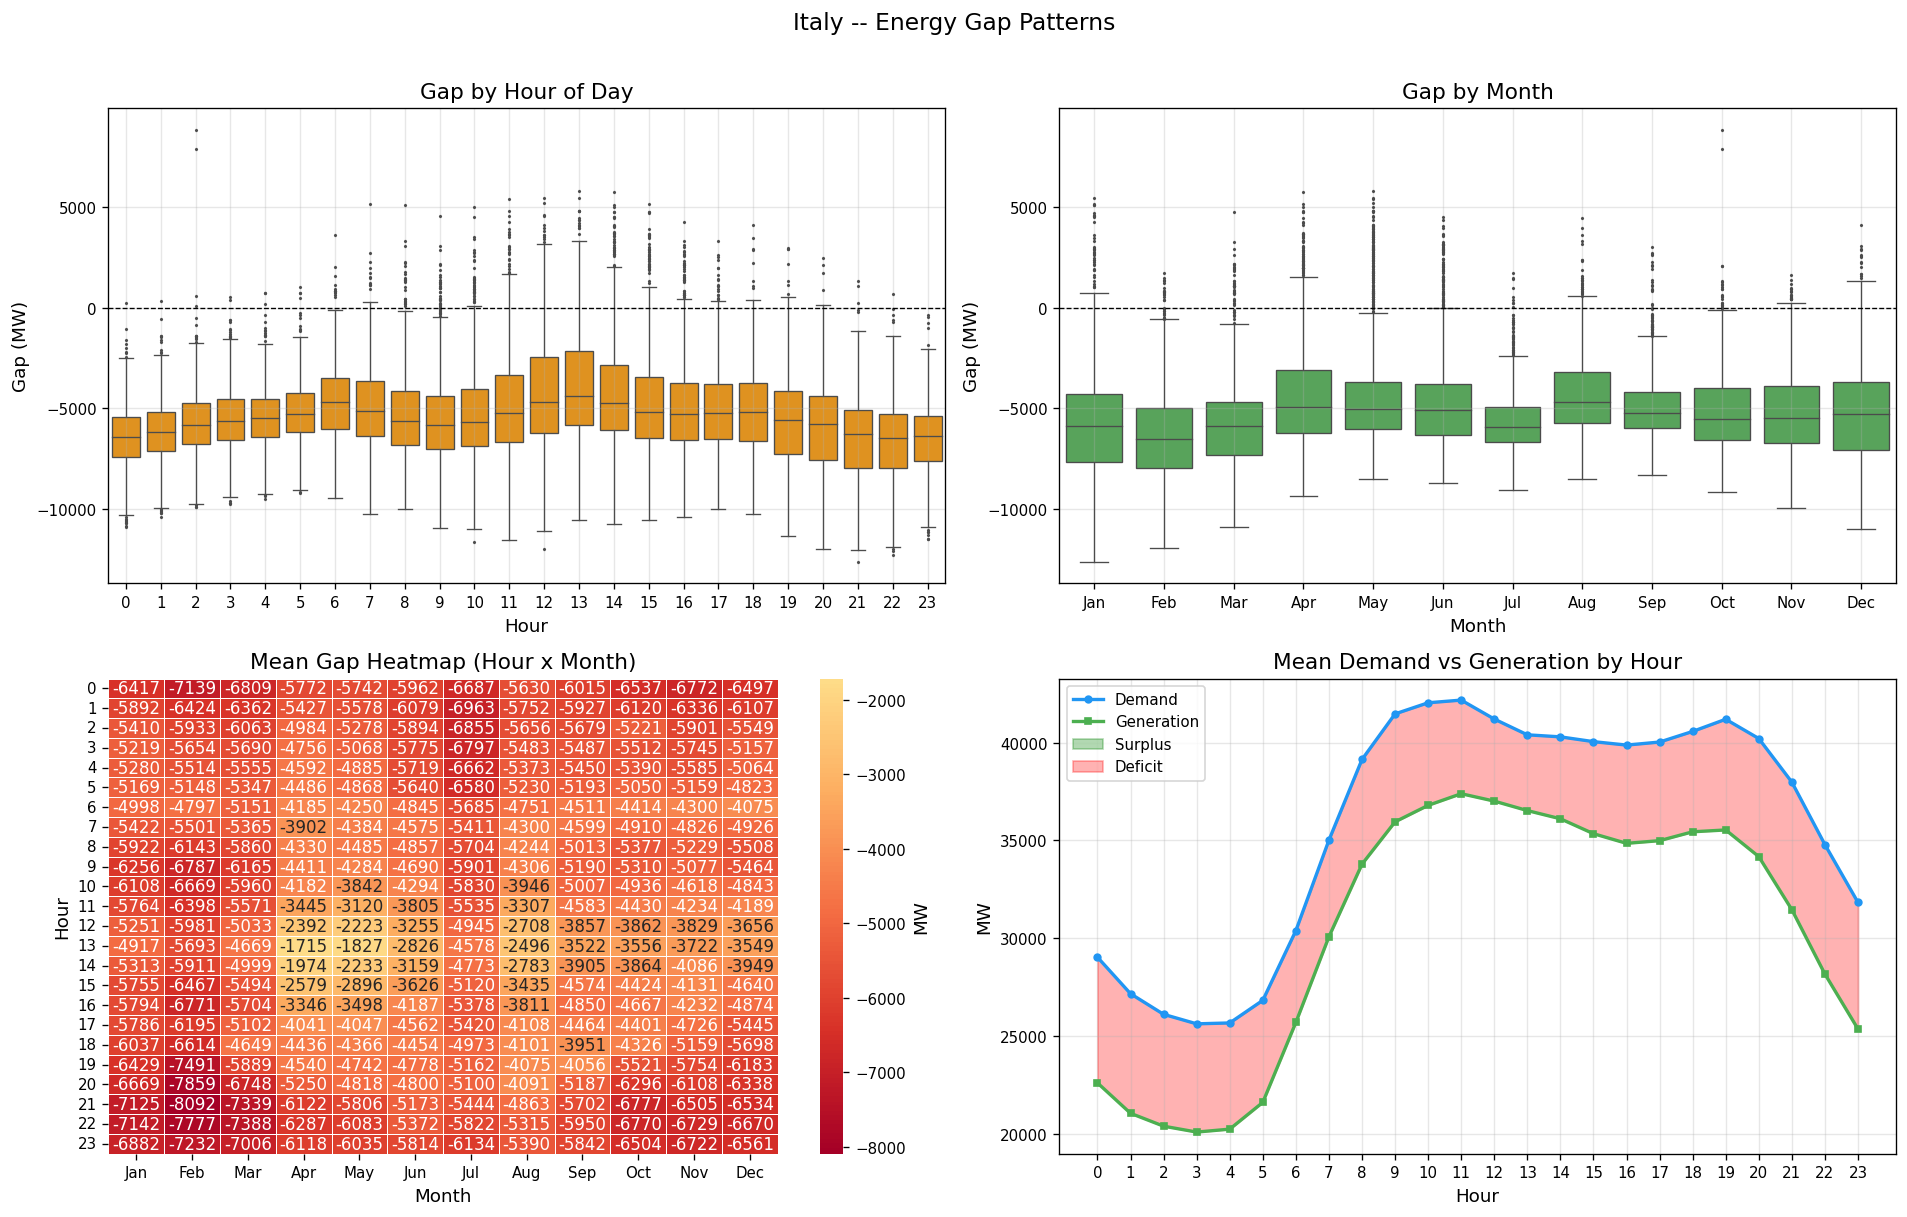

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (a) Gap by hour of day -- boxplot
sns.boxplot(data=eda, x="hour", y="Gap", ax=axes[0, 0],
            color="#FF9800", fliersize=1, linewidth=0.8)
axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0, 0].set_title("Gap by Hour of Day")
axes[0, 0].set_xlabel("Hour")
axes[0, 0].set_ylabel("Gap (MW)")
axes[0, 0].grid(alpha=0.3)

# (b) Gap by month -- boxplot
month_order = list(range(1, 13))
sns.boxplot(data=eda, x="month", y="Gap", ax=axes[0, 1], order=month_order,
            color="#4CAF50", fliersize=1, linewidth=0.8)
axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0, 1].set_title("Gap by Month")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Gap (MW)")
axes[0, 1].set_xticklabels([month_names[m] for m in month_order])
axes[0, 1].grid(alpha=0.3)

# (c) Mean Gap heatmap (hour x month)
pivot = eda.pivot_table(values="Gap", index="hour", columns="month", aggfunc="mean")
pivot.columns = [month_names[m] for m in pivot.columns]
sns.heatmap(pivot, cmap="RdYlGn", center=0, annot=True, fmt=".0f",
            linewidths=0.5, ax=axes[1, 0], cbar_kws={"label": "MW"})
axes[1, 0].set_title("Mean Gap Heatmap (Hour x Month)")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Hour")

# (d) Mean demand vs generation by hour
hourly_means = eda.groupby("hour")[["Demand", "Total_Generation"]].mean()
axes[1, 1].plot(hourly_means.index, hourly_means["Demand"], marker="o", markersize=4,
                color="#2196F3", linewidth=2, label="Demand")
axes[1, 1].plot(hourly_means.index, hourly_means["Total_Generation"], marker="s", markersize=4,
                color="#4CAF50", linewidth=2, label="Generation")
axes[1, 1].fill_between(hourly_means.index, hourly_means["Demand"], hourly_means["Total_Generation"],
                        where=hourly_means["Total_Generation"] >= hourly_means["Demand"],
                        alpha=0.3, color="green", label="Surplus")
axes[1, 1].fill_between(hourly_means.index, hourly_means["Demand"], hourly_means["Total_Generation"],
                        where=hourly_means["Total_Generation"] < hourly_means["Demand"],
                        alpha=0.3, color="red", label="Deficit")
axes[1, 1].set_title("Mean Demand vs Generation by Hour")
axes[1, 1].set_xlabel("Hour")
axes[1, 1].set_ylabel("MW")
axes[1, 1].set_xticks(range(0, 24))
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle("Italy -- Energy Gap Patterns", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4. Generation Mix Breakdown

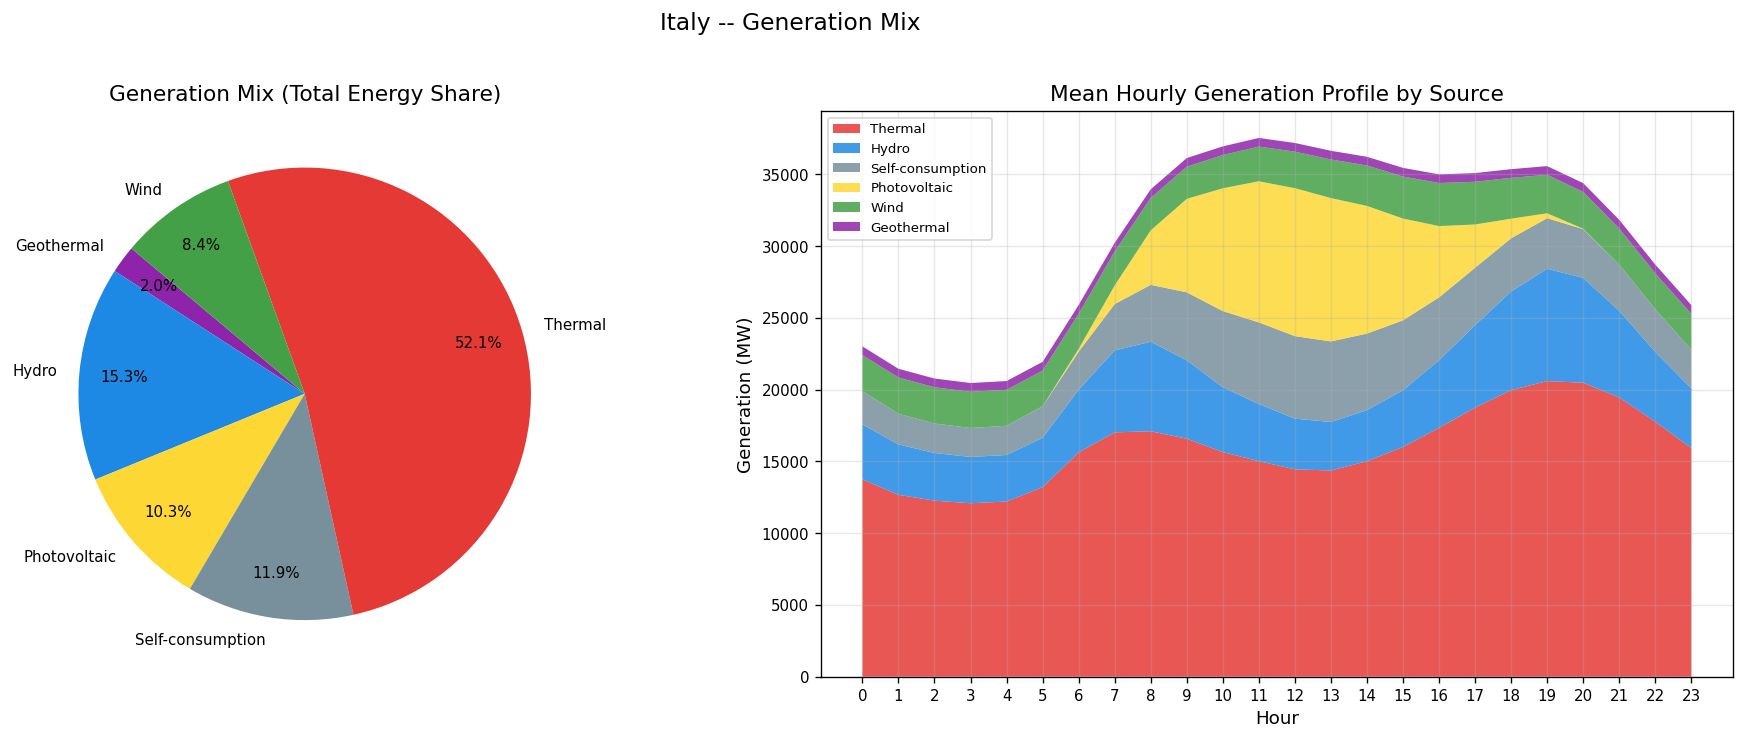

Generation mix (%):

  Thermal             :  52.1%
  Hydro               :  15.3%
  Self-consumption    :  11.9%
  Photovoltaic        :  10.3%
  Wind                :   8.4%
  Geothermal          :   2.0%


In [46]:
# Pivot generation sources from raw data
gen_by_source = (
    italy_gen_raw
    .assign(StartTime=lambda d: pd.to_datetime(d["Date"]))
    .set_index("StartTime")
    .pivot_table(values="Actual Generation", columns="Primary Source", aggfunc="sum")
)
gen_by_source = gen_by_source * 1000  # GW -> MW

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Pie chart of total generation by source
source_colors = {
    "Thermal": "#E53935", "Hydro": "#1E88E5", "Photovoltaic": "#FDD835",
    "Wind": "#43A047", "Geothermal": "#8E24AA", "Self-consumption": "#78909C"
}
totals = gen_by_source.iloc[0]  # from pivot_table with aggfunc=sum
colors = [source_colors.get(s, "#999") for s in totals.index]
wedges, texts, autotexts = axes[0].pie(
    totals.values, labels=totals.index, autopct="%1.1f%%",
    colors=colors, startangle=140, pctdistance=0.8
)
for t in autotexts:
    t.set_fontsize(9)
axes[0].set_title("Generation Mix (Total Energy Share)")

# (b) Hourly generation profile by source (stacked area)
gen_hourly = (
    italy_gen_raw
    .assign(StartTime=pd.to_datetime(italy_gen_raw["Date"]),
            Gen_MW=italy_gen_raw["Actual Generation"] * 1000)
    .assign(hour=lambda d: d["StartTime"].dt.hour)
    .pivot_table(values="Gen_MW", index="hour", columns="Primary Source", aggfunc="mean")
)
# Reorder columns by total contribution
col_order = gen_hourly.sum().sort_values(ascending=False).index
gen_hourly = gen_hourly[col_order]
stack_colors = [source_colors.get(s, "#999") for s in gen_hourly.columns]
axes[1].stackplot(gen_hourly.index, gen_hourly.values.T,
                  labels=gen_hourly.columns, colors=stack_colors, alpha=0.85)
axes[1].set_title("Mean Hourly Generation Profile by Source")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Generation (MW)")
axes[1].set_xticks(range(0, 24))
axes[1].legend(loc="upper left", fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle("Italy -- Generation Mix", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print generation mix percentages
pct = (totals / totals.sum() * 100).sort_values(ascending=False)
print("Generation mix (%):\n")
for src, val in pct.items():
    print(f"  {src:20s}: {val:5.1f}%")

### 5. Weather vs Energy Correlation

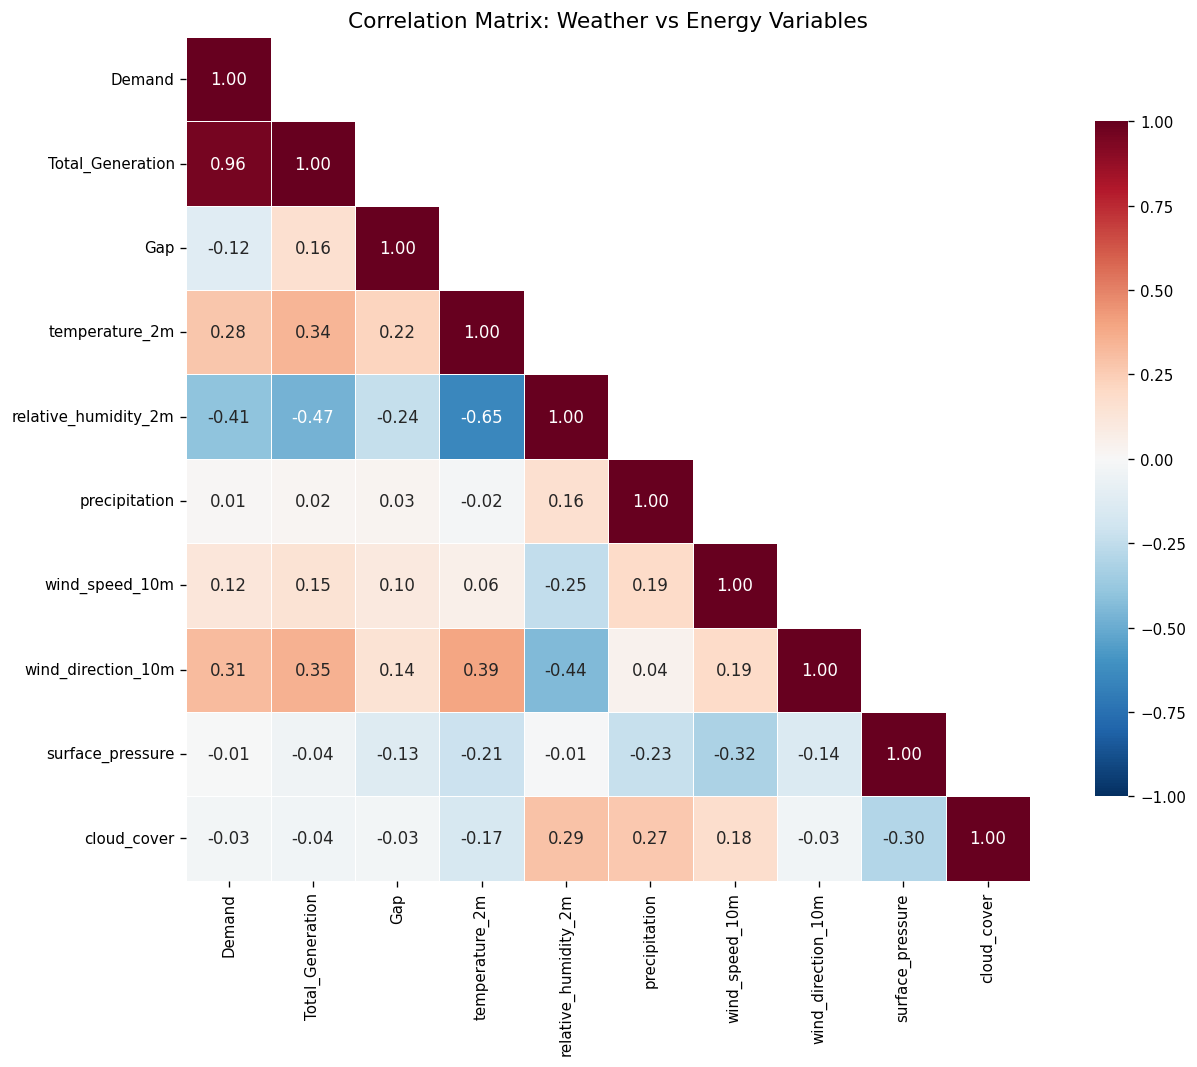

In [47]:
weather_cols = ["temperature_2m", "relative_humidity_2m", "precipitation",
                "wind_speed_10m", "wind_direction_10m", "surface_pressure", "cloud_cover"]
energy_cols = ["Demand", "Total_Generation", "Gap"]
corr_cols = energy_cols + weather_cols
corr_matrix = eda[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix: Weather vs Energy Variables", fontsize=13)
plt.tight_layout()
plt.show()

### 6. Seasonal and Day-of-Week Patterns

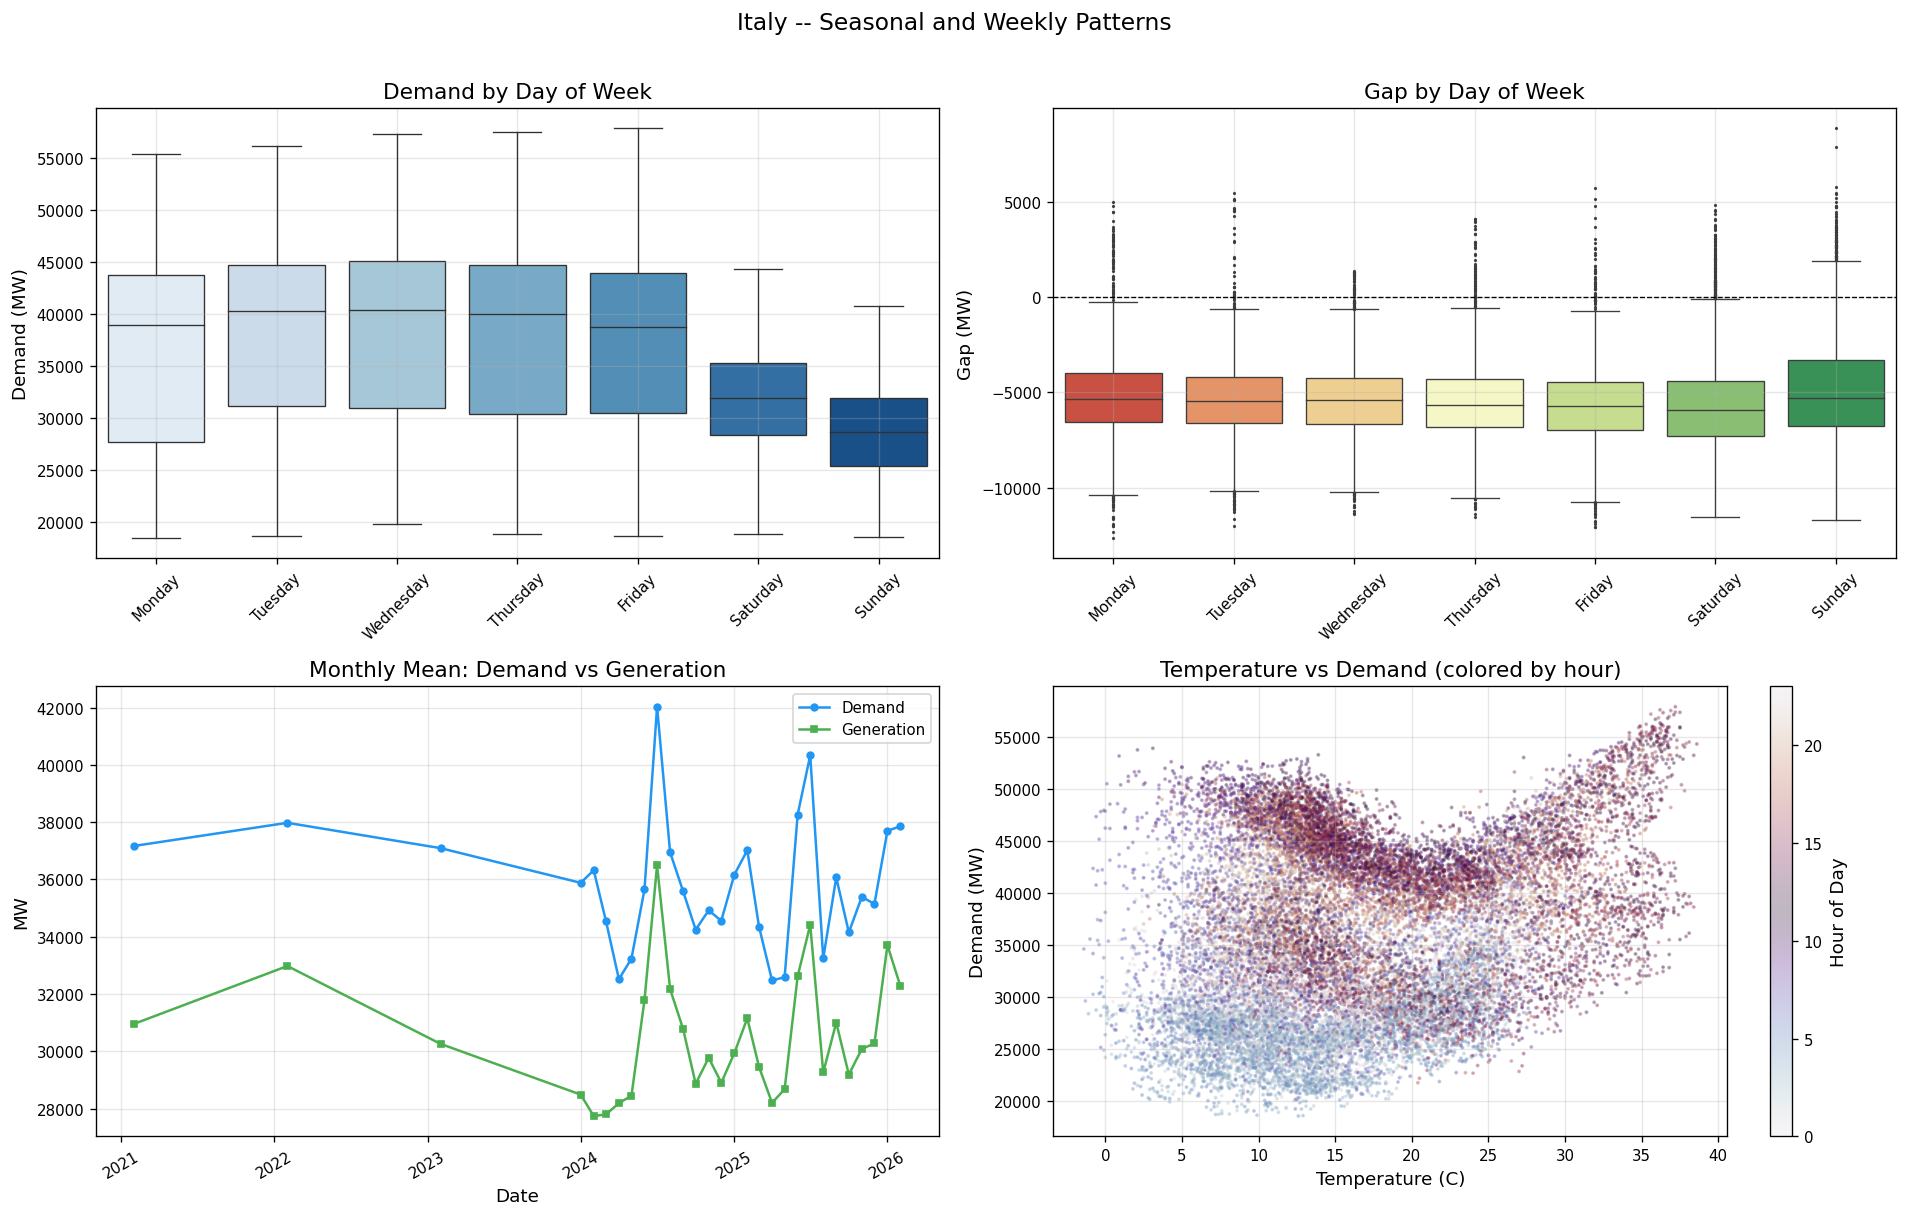

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (a) Demand by day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.boxplot(data=eda, x="day_name", y="Demand", order=day_order,
            ax=axes[0, 0], palette="Blues", fliersize=1, linewidth=0.8)
axes[0, 0].set_title("Demand by Day of Week")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Demand (MW)")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(alpha=0.3)

# (b) Gap by day of week
sns.boxplot(data=eda, x="day_name", y="Gap", order=day_order,
            ax=axes[0, 1], palette="RdYlGn", fliersize=1, linewidth=0.8)
axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0, 1].set_title("Gap by Day of Week")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Gap (MW)")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].grid(alpha=0.3)

# (c) Monthly mean demand across years
monthly = eda.groupby(["year", "month"])[["Demand", "Total_Generation"]].mean().reset_index()
monthly["date"] = pd.to_datetime(monthly[["year", "month"]].assign(day=1))
axes[1, 0].plot(monthly["date"], monthly["Demand"], marker="o", markersize=4,
                color="#2196F3", linewidth=1.5, label="Demand")
axes[1, 0].plot(monthly["date"], monthly["Total_Generation"], marker="s", markersize=4,
                color="#4CAF50", linewidth=1.5, label="Generation")
axes[1, 0].set_title("Monthly Mean: Demand vs Generation")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("MW")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].tick_params(axis="x", rotation=30)

# (d) Temperature vs Demand scatter
sc = axes[1, 1].scatter(eda["temperature_2m"], eda["Demand"],
                        c=eda["hour"], cmap="twilight", s=2, alpha=0.3)
axes[1, 1].set_title("Temperature vs Demand (colored by hour)")
axes[1, 1].set_xlabel("Temperature (C)")
axes[1, 1].set_ylabel("Demand (MW)")
axes[1, 1].grid(alpha=0.3)
cbar = plt.colorbar(sc, ax=axes[1, 1], label="Hour of Day")

plt.suptitle("Italy -- Seasonal and Weekly Patterns", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 7. Gap Surplus/Deficit Summary

Total hours in dataset: 20,663
Surplus hours (Gap >= 0): 631 (3.1%)
Deficit hours (Gap < 0):  20,032 (96.9%)

Mean Gap:       -5,351 MW
Median Gap:     -5,551 MW
Std Gap:         2,352 MW
Min Gap:       -12,635 MW  (worst deficit)
Max Gap:         8,868 MW  (peak surplus)



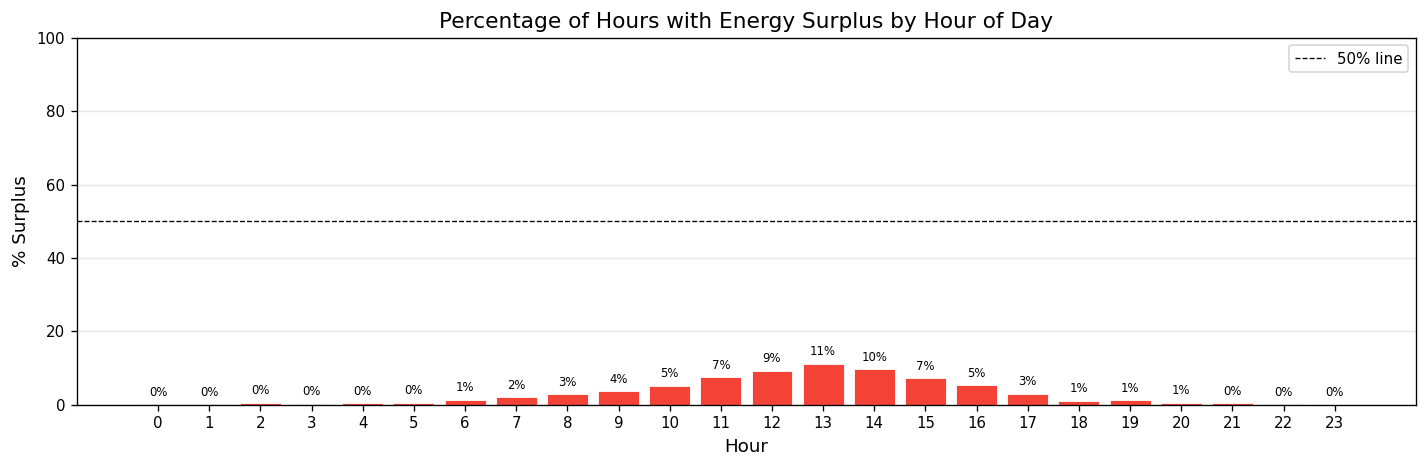

In [49]:
surplus_pct = (eda["Gap"] >= 0).mean() * 100
deficit_pct = (eda["Gap"] < 0).mean() * 100

print(f"Total hours in dataset: {len(eda):,}")
print(f"Surplus hours (Gap >= 0): {int((eda['Gap'] >= 0).sum()):,} ({surplus_pct:.1f}%)")
print(f"Deficit hours (Gap < 0):  {int((eda['Gap'] < 0).sum()):,} ({deficit_pct:.1f}%)")
print(f"")
print(f"Mean Gap:   {eda['Gap'].mean():>10,.0f} MW")
print(f"Median Gap: {eda['Gap'].median():>10,.0f} MW")
print(f"Std Gap:    {eda['Gap'].std():>10,.0f} MW")
print(f"Min Gap:    {eda['Gap'].min():>10,.0f} MW  (worst deficit)")
print(f"Max Gap:    {eda['Gap'].max():>10,.0f} MW  (peak surplus)")
print()

# Deficit/surplus by hour
hourly_gap_sign = eda.groupby("hour")["Gap"].apply(lambda x: (x >= 0).mean() * 100)
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(hourly_gap_sign.index, hourly_gap_sign.values,
              color=["#4CAF50" if v >= 50 else "#F44336" for v in hourly_gap_sign.values],
              edgecolor="white", linewidth=0.5)
ax.axhline(50, color="black", linestyle="--", linewidth=0.8, label="50% line")
ax.set_title("Percentage of Hours with Energy Surplus by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("% Surplus")
ax.set_xticks(range(0, 24))
ax.set_ylim(0, 100)
ax.legend()
ax.grid(alpha=0.3, axis="y")
for bar, val in zip(bars, hourly_gap_sign.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{val:.0f}%", ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.show()